In [ ]:
!nvidia-smi

Wed Aug 19 21:53:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
%pip install ultralytics supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 47.2/235.7 GB disk)


In [ ]:
!yolo task=detect mode=predict model=yolo12n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv12n summary (fused): 159 layers, 2,590,824 parameters, 0 gradients, 7.5 GFLOPs

image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 2 dogs, 14.6ms
Speed: 64.5ms preprocess, 14.6ms inference, 38.7ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


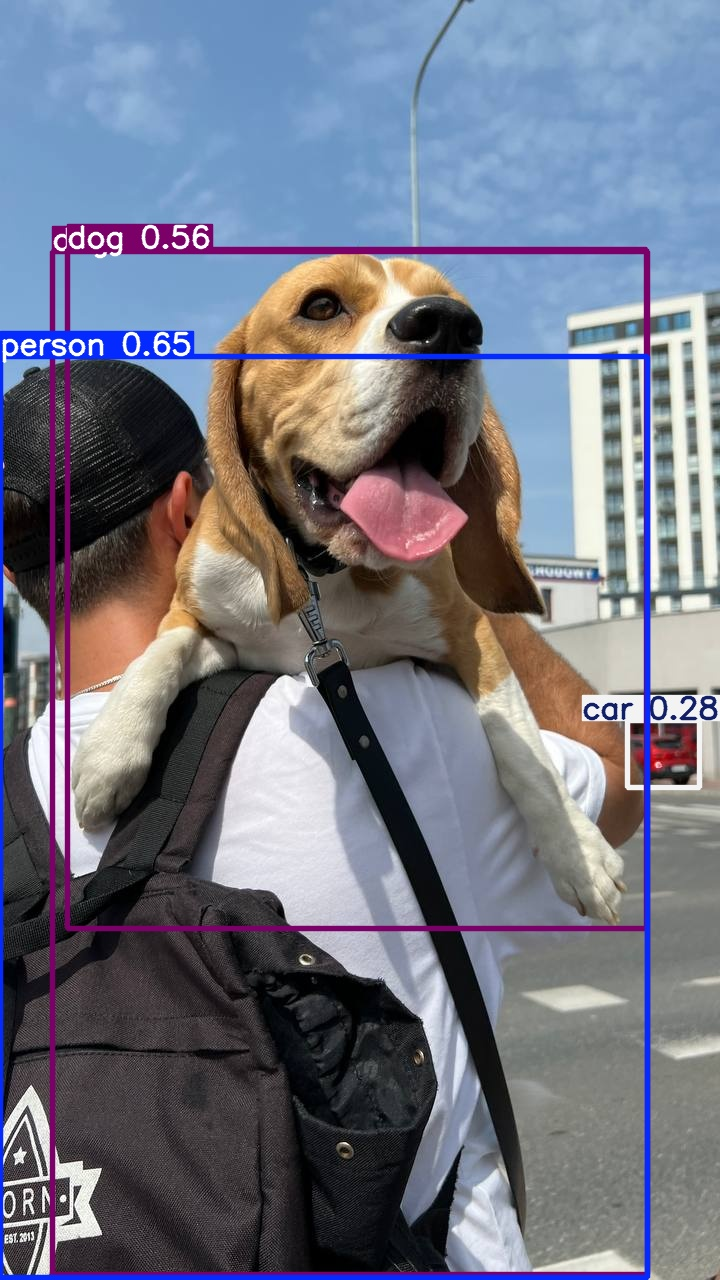

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo12n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 1 person, 1 car, 2 dogs, 14.4ms
Speed: 23.8ms preprocess, 14.4ms inference, 19.1ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
result.boxes.xyxy

tensor([[2.3889e-01, 3.5632e+02, 6.4728e+02, 1.2772e+03],
        [6.7420e+01, 2.4998e+02, 6.4616e+02, 9.2836e+02],
        [5.2010e+01, 2.5117e+02, 6.4709e+02, 1.2749e+03],
        [6.2766e+02, 7.2024e+02, 6.9907e+02, 7.8794e+02]], device='cuda:0')

In [ ]:
result.boxes.conf

tensor([0.6469, 0.5587, 0.5165, 0.2766], device='cuda:0')

In [ ]:
result.boxes.cls

tensor([ 0., 16., 16.,  2.], device='cuda:0')

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

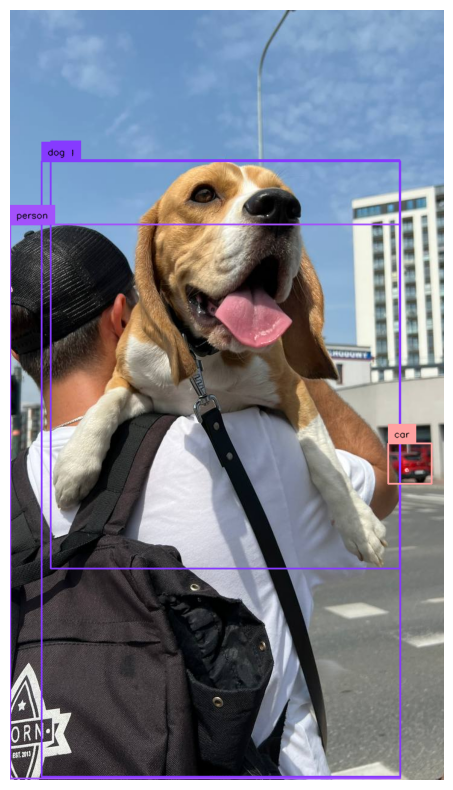

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("renaire-odarve")
project = workspace.project("erotica-detection")
version = project.version(4)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to erotica-detection-4 in yolov11:: 100%|██████████| 31628/31628 [00:03<00:00, 8630.14it/s] 


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo12n.pt data={dataset.location}/data.yaml epochs=150 imgsz=640 plots=True

/content
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/erotica-detection-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch96880.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch96881.jpg  weights
labels.jpg			 train_batch96882.jpg


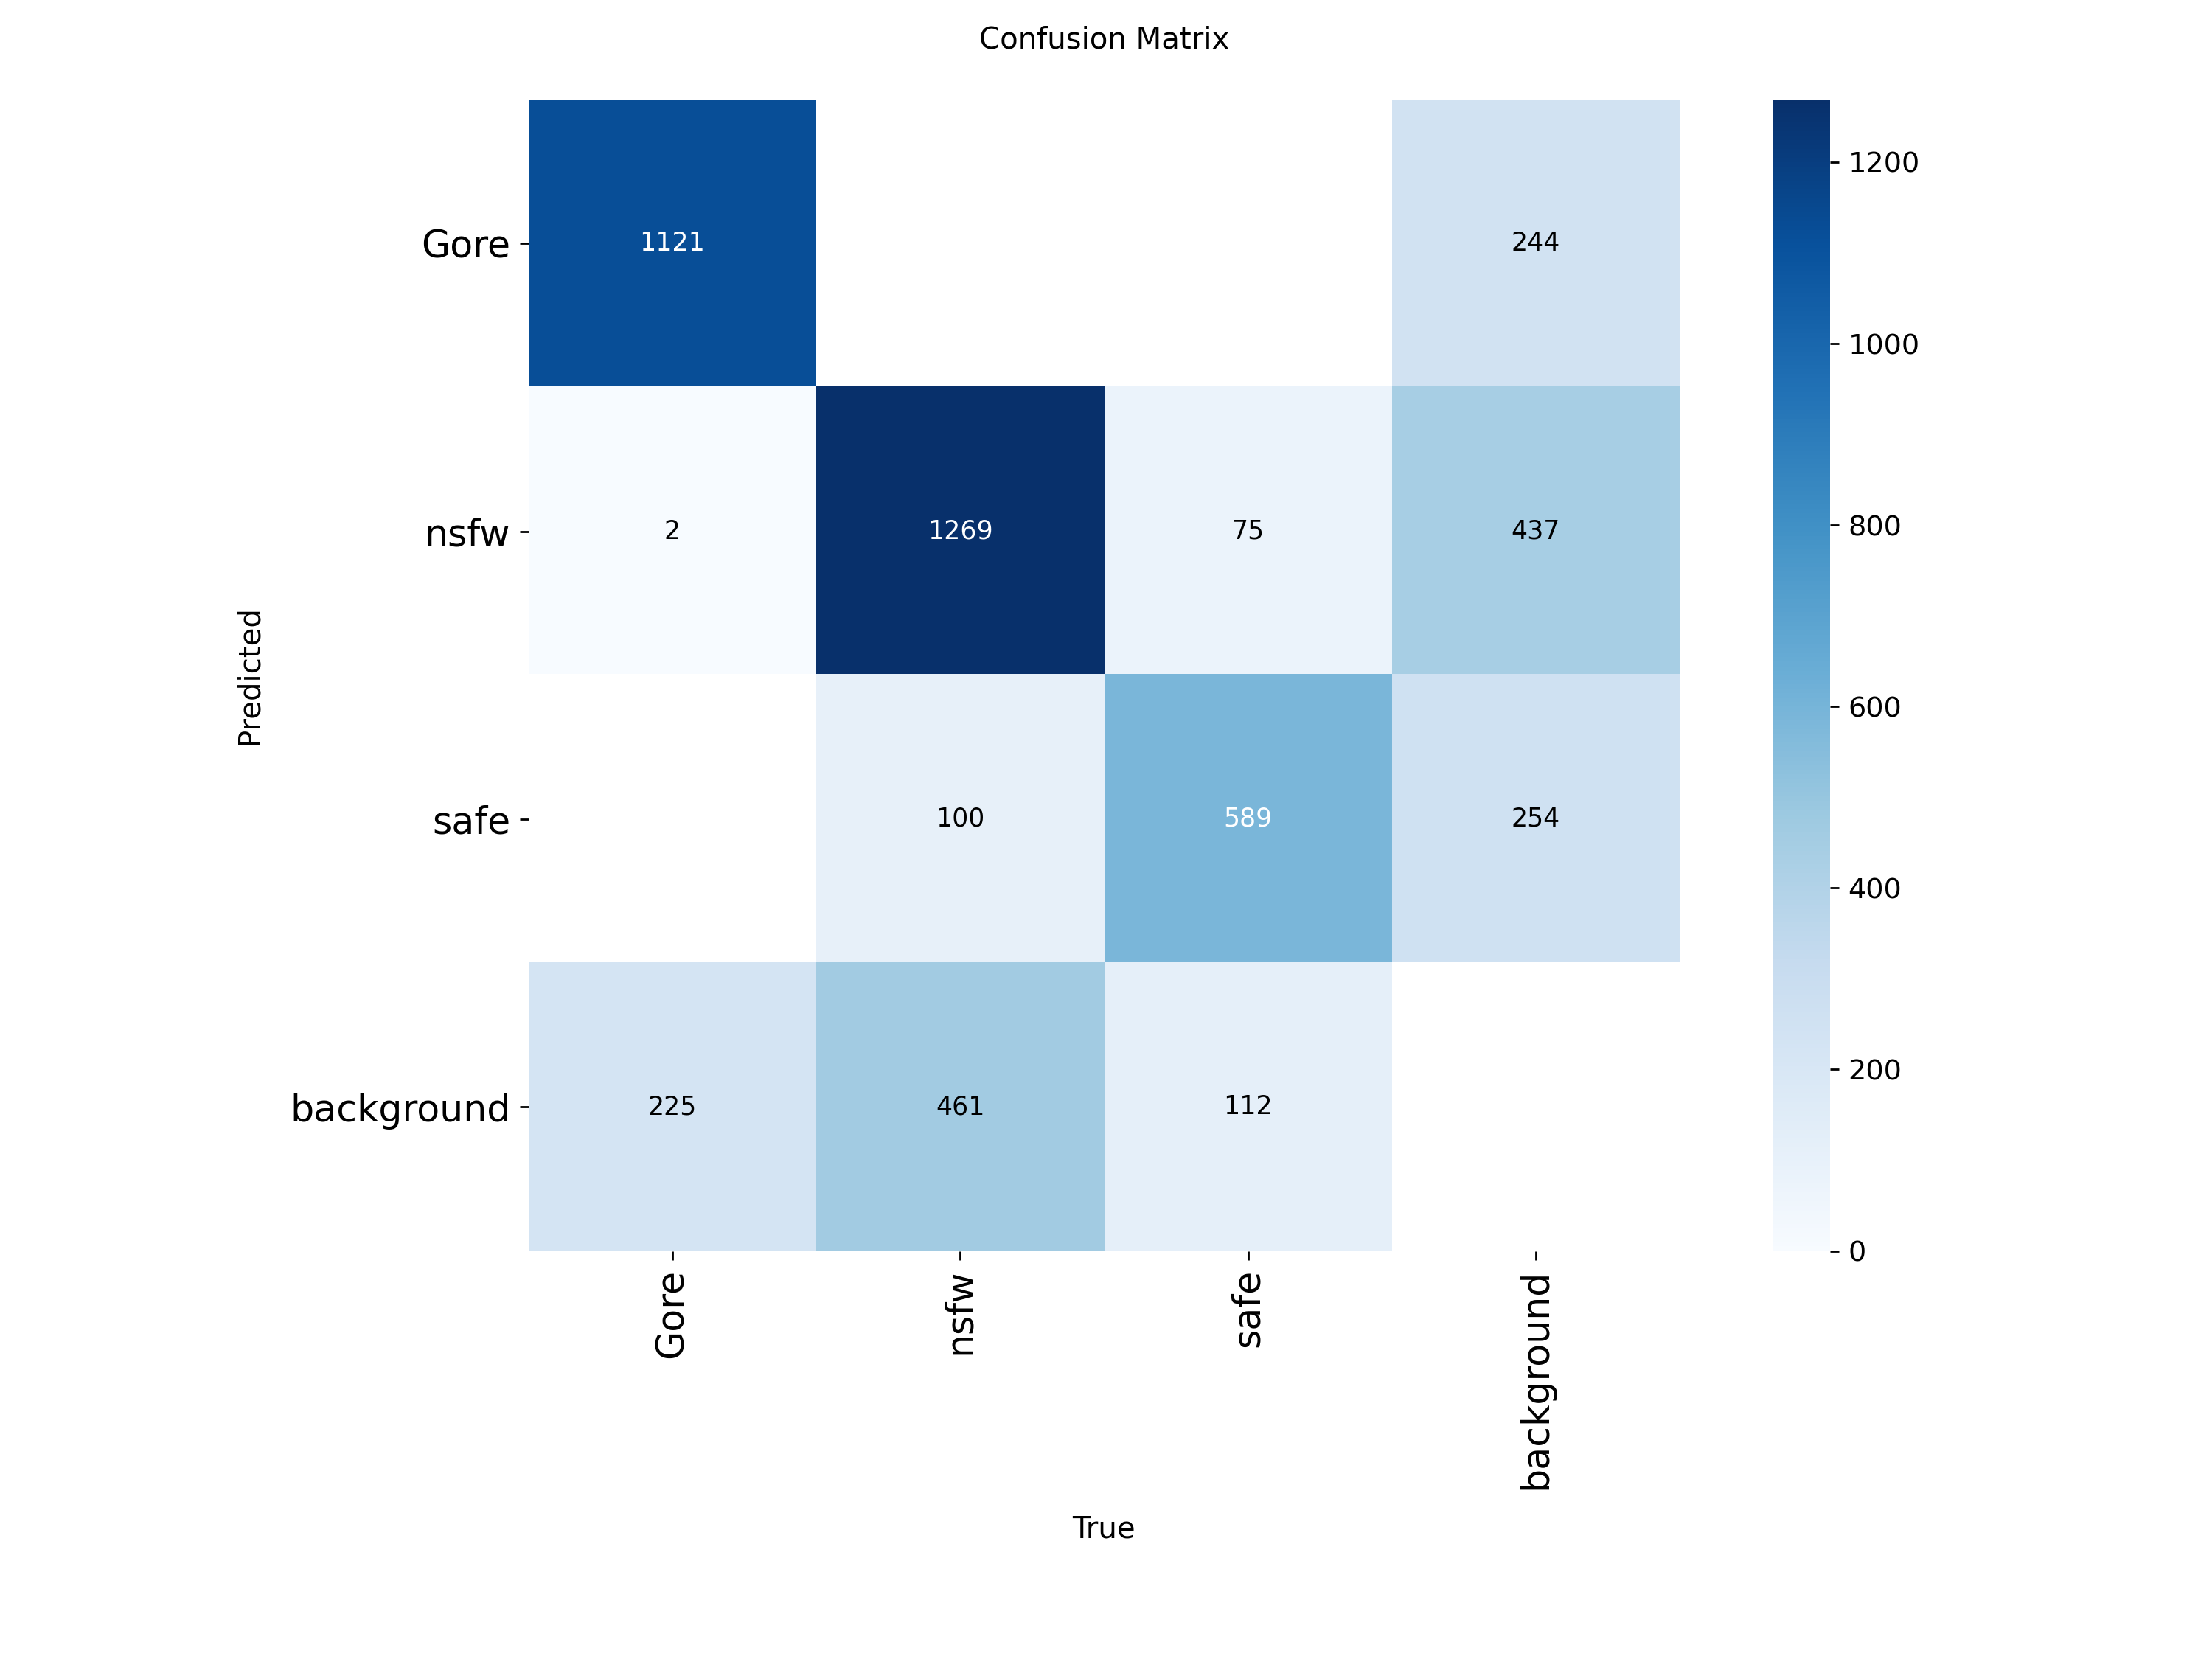

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

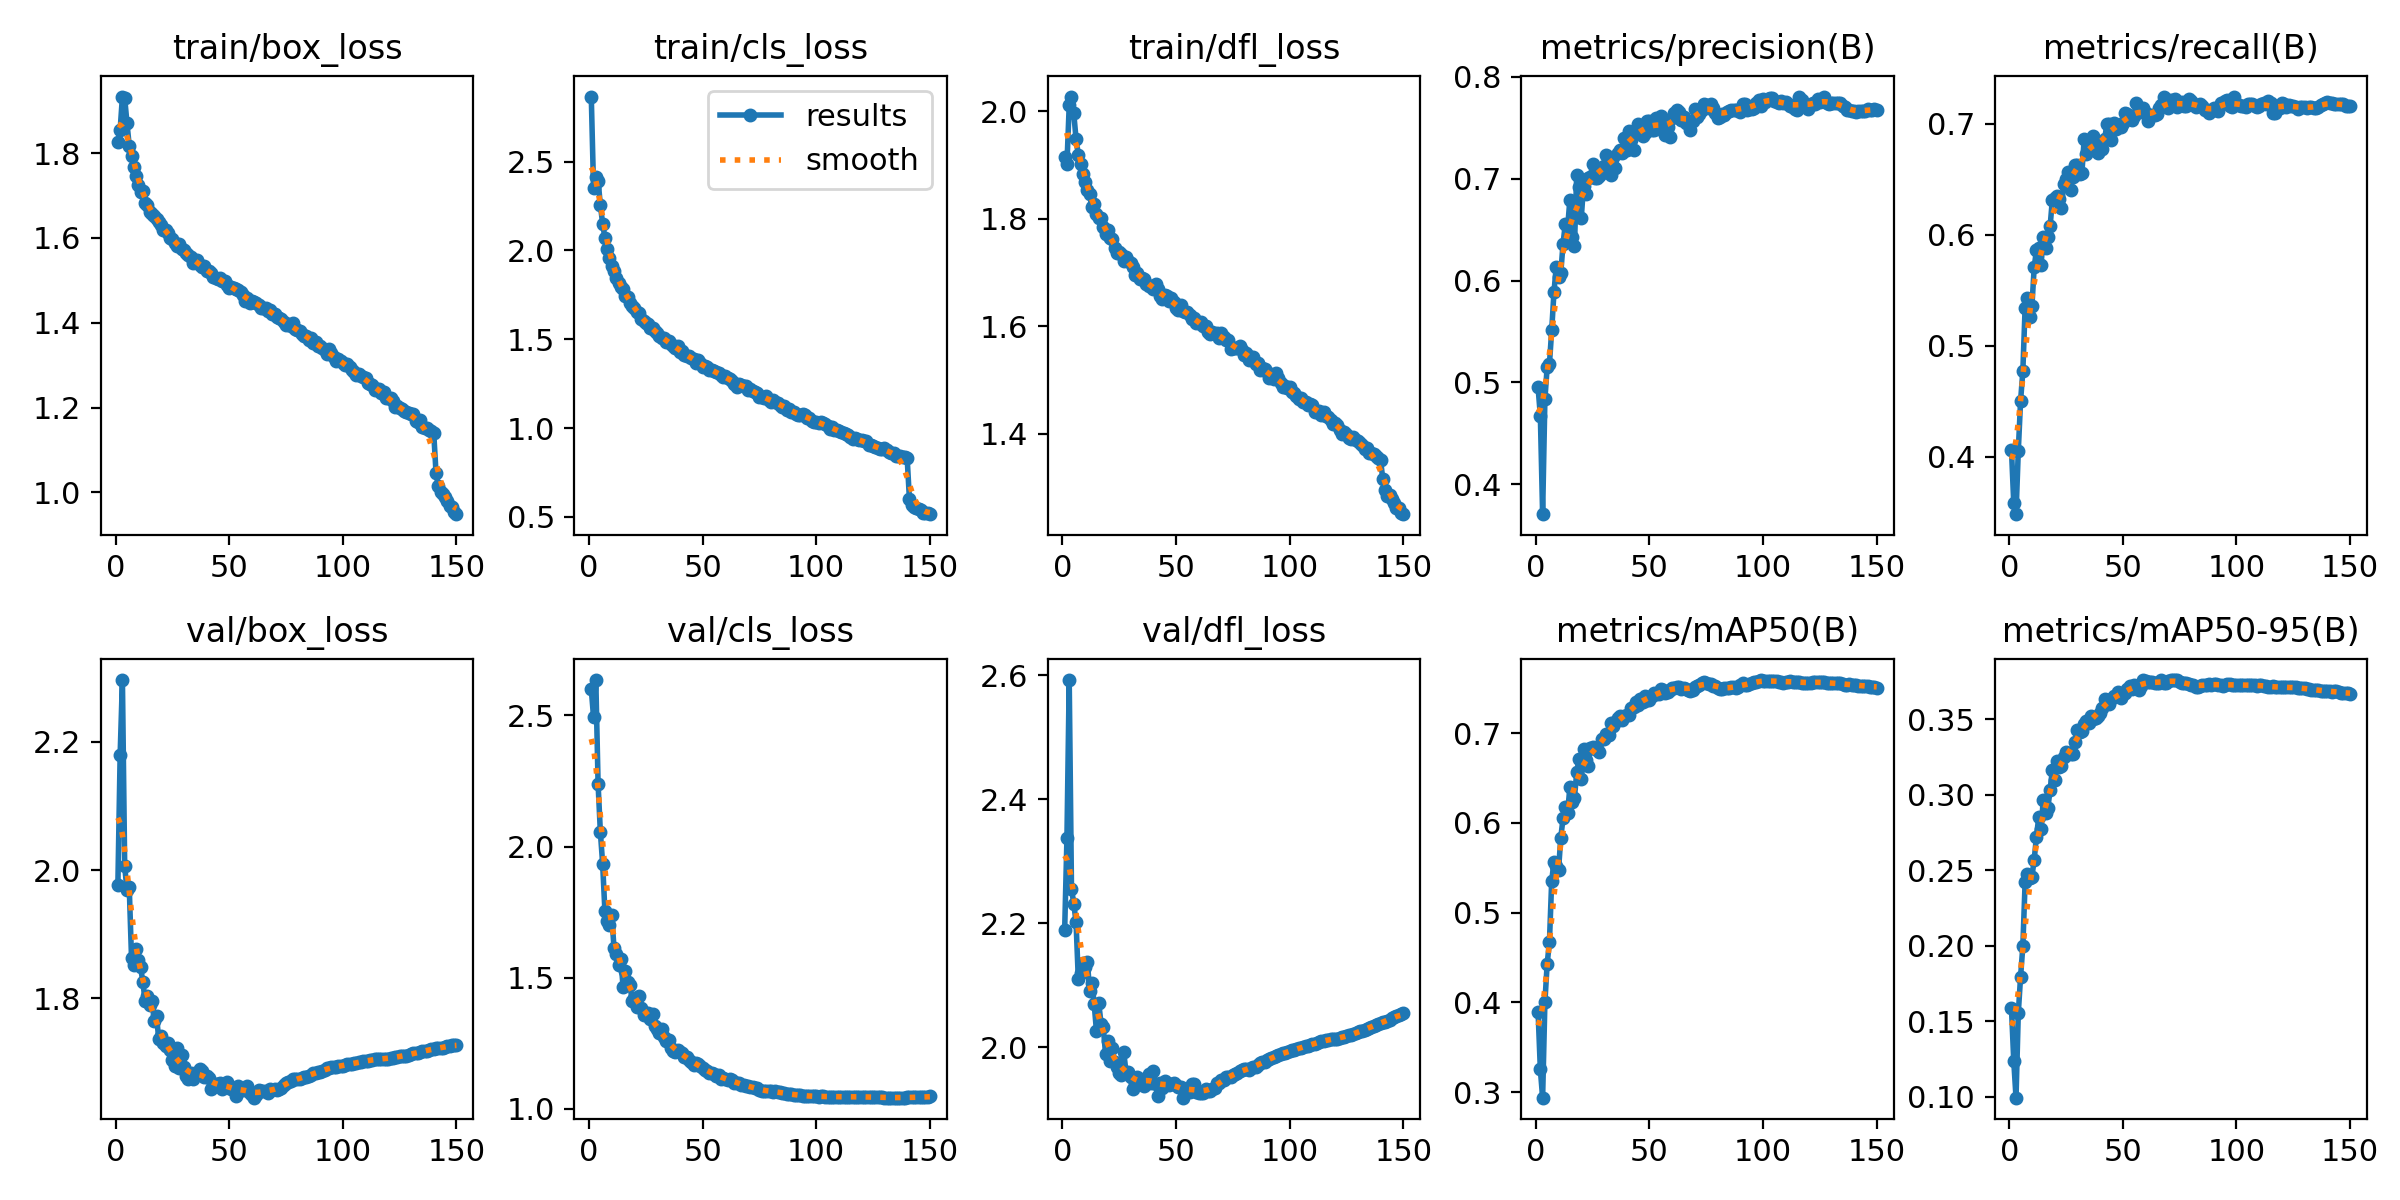

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

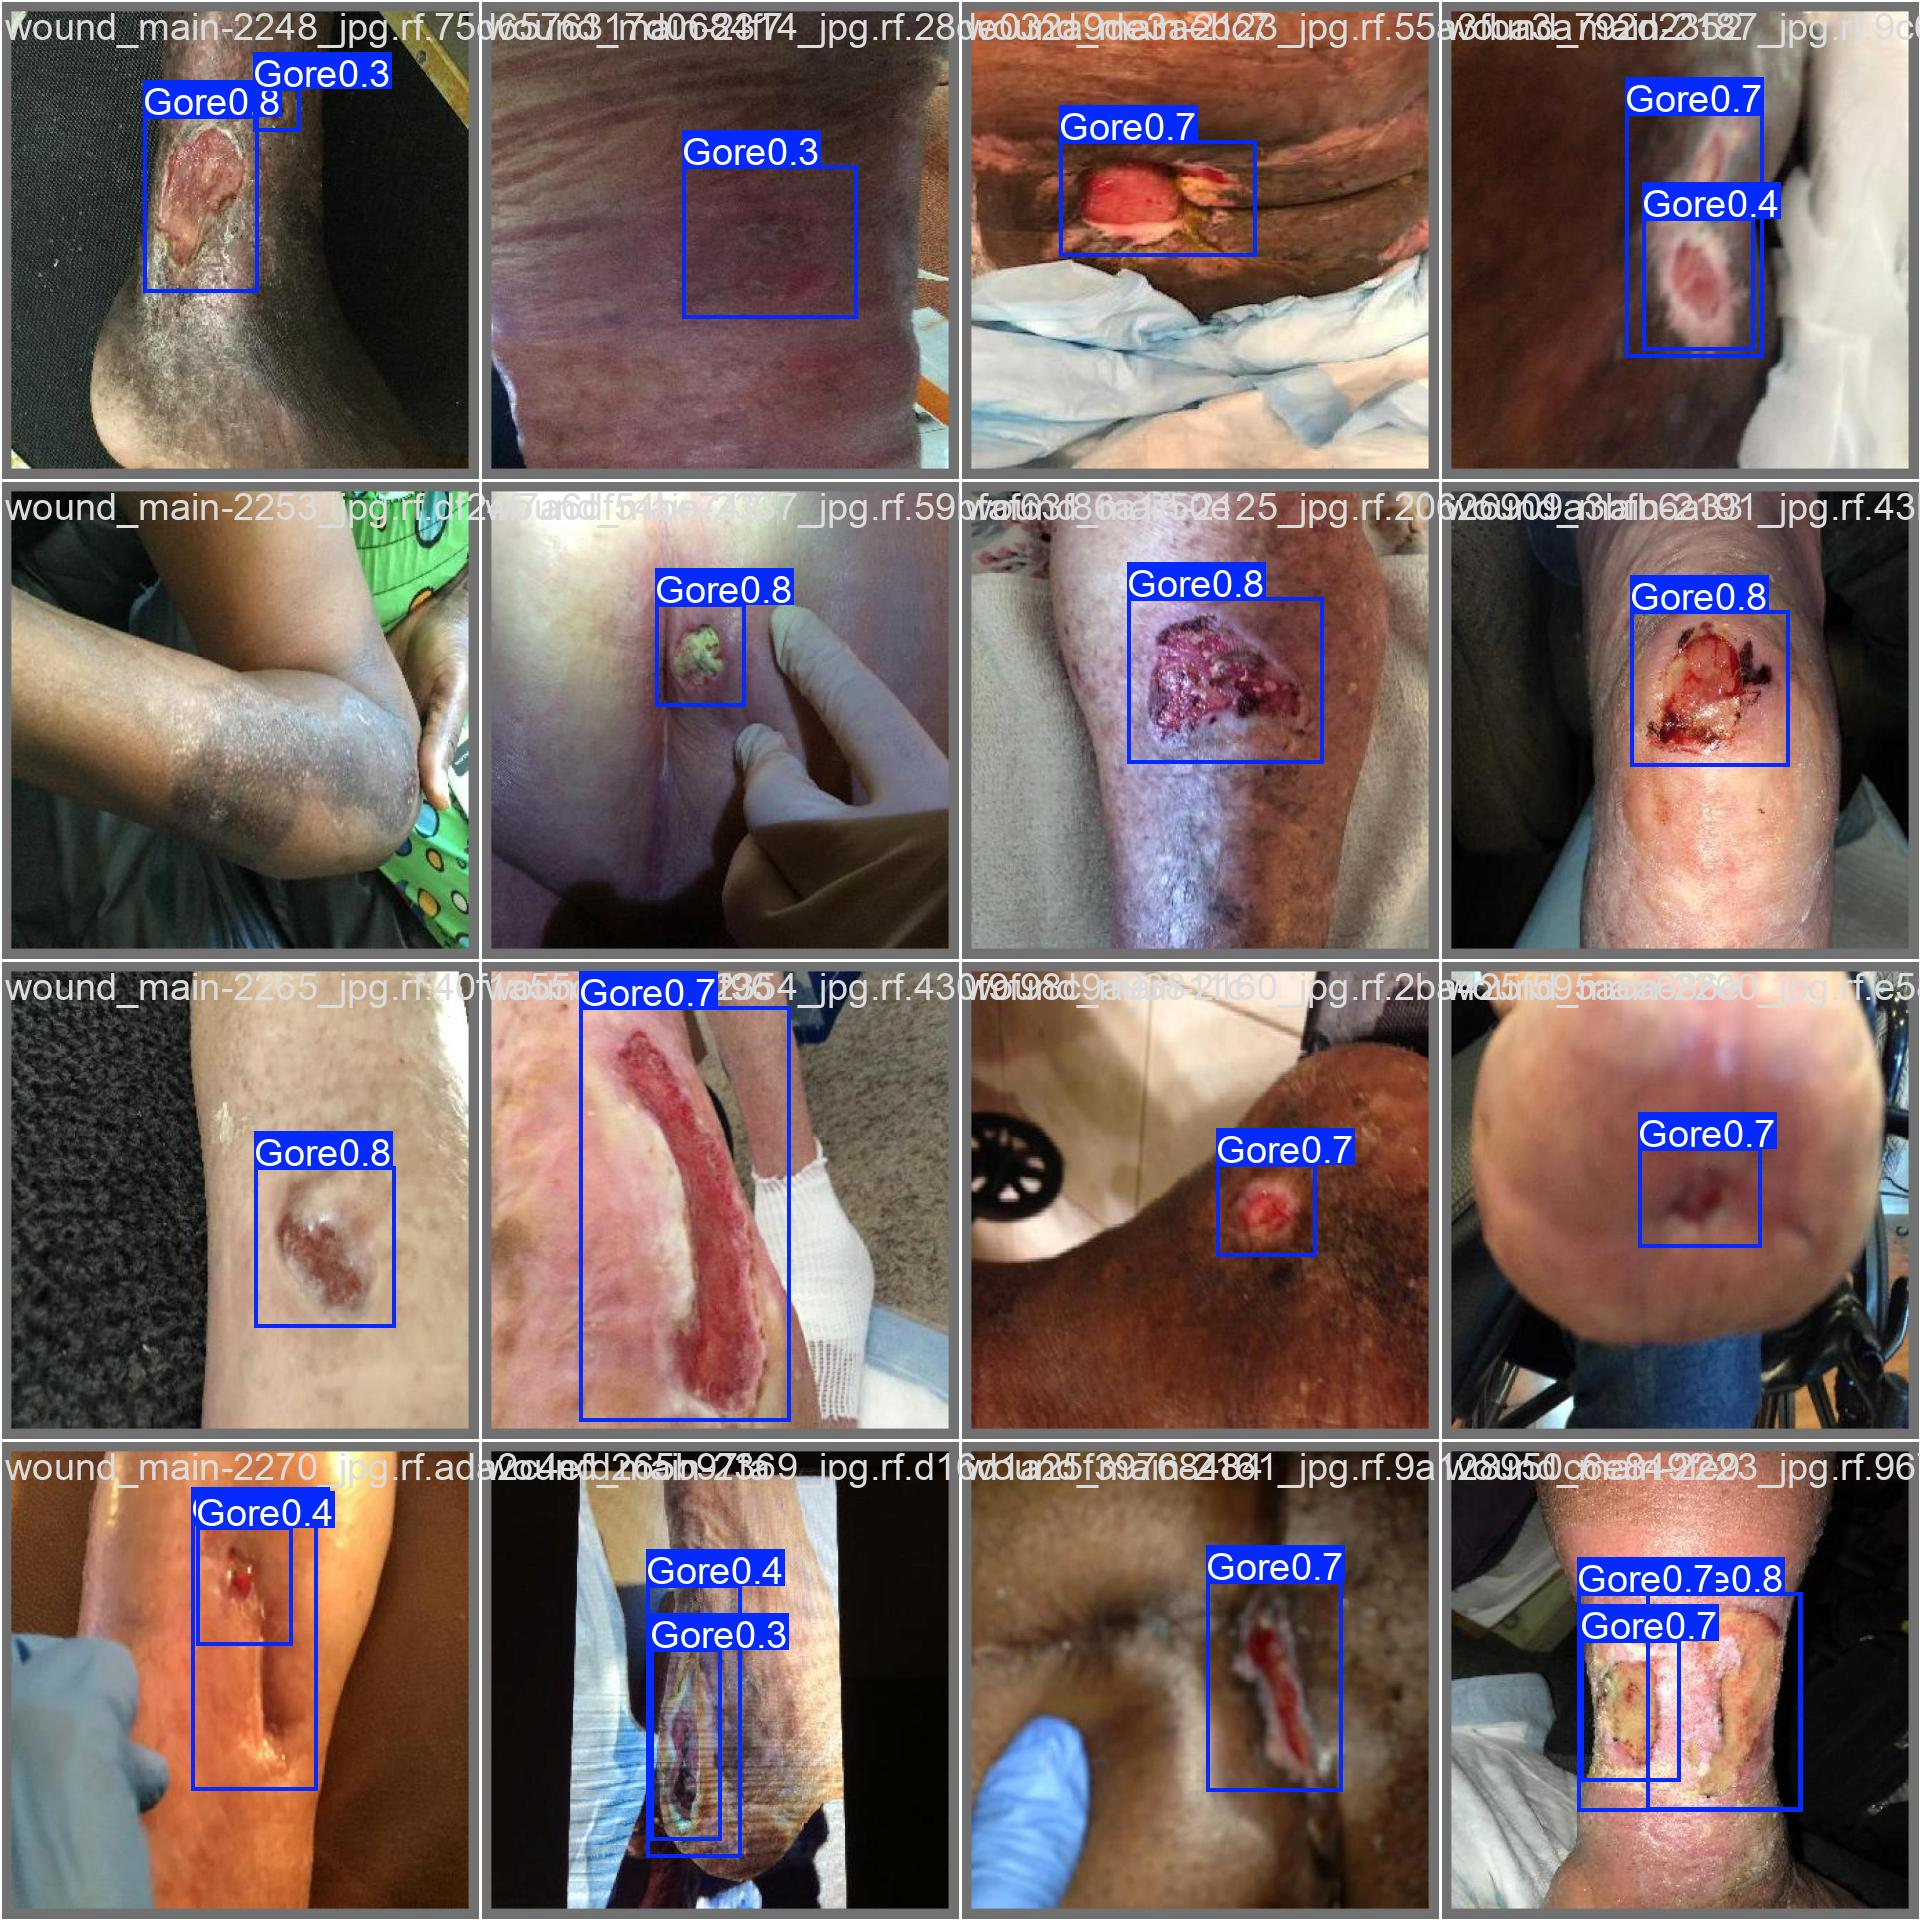

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1648.0±367.6 MB/s, size: 44.0 KB)
val: Scanning /content/datasets/erotica-detection-4/valid/labels.cache... 2416 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2416/2416 440.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 11.9it/s 12.6s
                   all       2416       3954      0.763      0.717      0.753      0.376
                  Gore       1025       1348      0.858      0.793      0.872      0.523
                  nsfw        978       1830      0.745      0.632      0.687      0.311
                  safe        520        776      0.686      0.727      0.701      0.294
Speed: 0.6ms preprocess, 1.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results s

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs

image 1/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0000-978B3Ab05B7D2D1179E42B02C89Bd98875D1Bd38-01E2H07W3_jpg.rf.fdd846755455ae656df403e62f440965.jpg: 640x640 2 nsfws, 14.5ms
image 2/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0001-6-01G12Q6Djrcnq295Zx6Tpnwtaw1680X0_jpg.rf.dd8fb3ba0cc82f539367f433c03e747e.jpg: 640x640 3 nsfws, 14.9ms
image 3/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0005-10-01G145H5V5Z86Gfbhhzqfbqkbv1680X0_jpg.rf.b88ff47921aa69035cc45a3f4ea578a6.jpg: 640x640 2 nsfws, 13.5ms
image 4/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0007-K15Ujdhhans81-01G0N767Qxfk8F3Bpvkdbg8Bws640X0_jpg.rf.6fab970148da2e8dfeb8db40f7cf0803.jpg: 640x640 2 nsfws, 13.4ms
image 5/2327 /content/datasets/erotica-detection-4/test/images

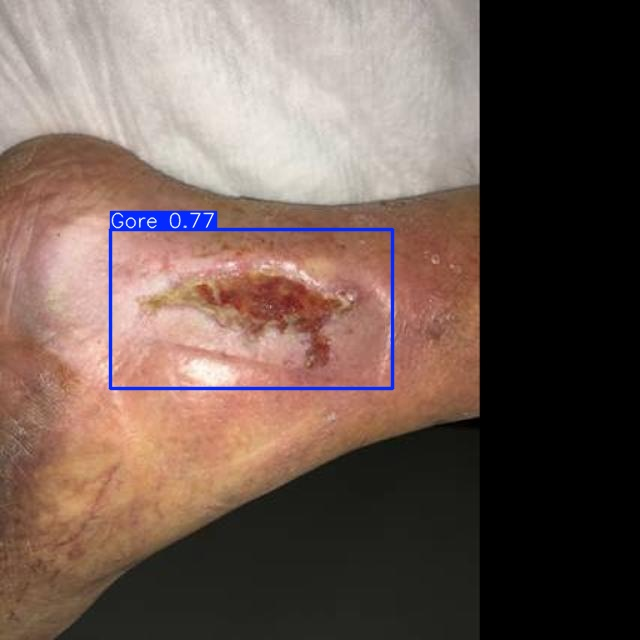

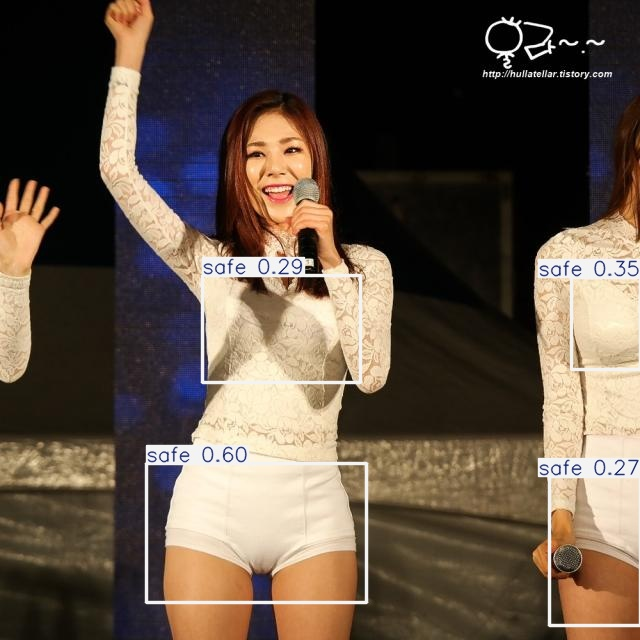

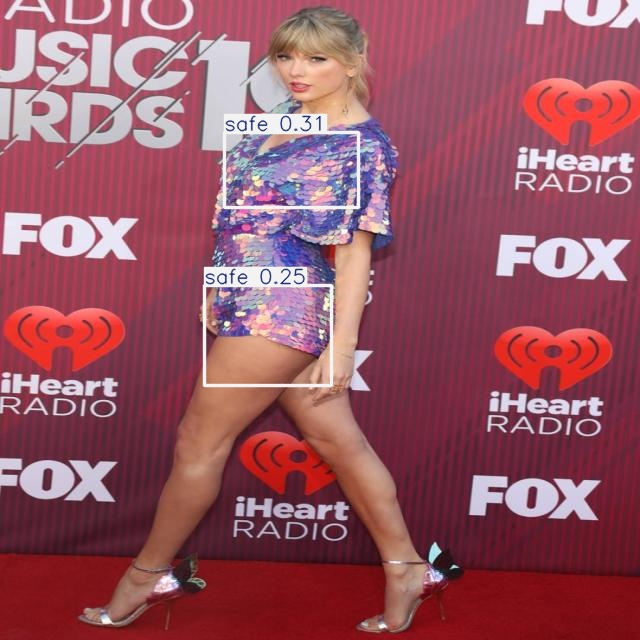

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [ ]:
model.export(format="tflite")

WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert/
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolo12n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.3 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 85 packages in 670ms
Prepared 15 packages in 1.56s
Uninstalled 3 packages in 23ms
Installed 15 packages in 21ms
 + ai-edge-litert==2.1.6
 + ai-edge-quantizer==0.8.0
 + backports-strenum==1.3.1
 + fire==0.7.1
 - immutabledict==4.3.1
 + immutabledict==4.2.1
 + jaxtyping==0.3.1

invalid escape sequence '\.'



LiteRT: starting export with litert_torch 0.9.3...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:21) [ DONE] LiteRT-Torch Convert (+00:21)

(00:00) [START] Write Model to yolo12n.tflite

(00:00) [ DONE] Write Model to yolo12n.tflite (+00:00)

LiteRT: export success ✅ 27.0s, saved as 'yolo12n.tflite' (10.3 MB)

Export complete (27.3s)
Results saved to /content/yolo12n.tflite
Predict:         yolo predict task=detect model=yolo12n.tflite imgsz=640 
Validate:        yolo val task=detect model=yolo12n.tflite imgsz=640 data=None  
Visualize:       https://netron.app


PosixPath('yolo12n.tflite')

In [ ]:
# Zip the results folder
!zip -r yolov12n_results.zip /content/runs/detect/train/

  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/BoxP_curve.png (deflated 10%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 8%)
  adding: content/runs/detect/train/train_batch96881.jpg (deflated 7%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 27%)
  adding: content/runs/detect/train/labels.jpg (deflated 25%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 3%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/best.pt (deflated 11%)
  adding: content/runs/detect/train/weights/last.pt (deflated 11%)
  adding: content/runs/detect/train/results.csv (deflated 69%)
  adding: content/runs/detect/train/val_batch2_labels.jpg (deflated 10%)
  adding: content/runs/detect/train/train_batch96880.jpg (deflated 9%)
  adding: content/runs/detect/train/val_batch1_pred.jpg (deflated 7%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflate

In [ ]:
# Zip the saved model folder
!zip -r yolov12n_saved_model.zip /content/yolo12n_saved_model

	zip warning: name not matched: /content/yolo12n_saved_model

zip error: Nothing to do! (try: zip -r yolov12n_saved_model.zip . -i /content/yolo12n_saved_model)


In [ ]:
from google.colab import files

files.download('yolov12n_results.zip')

files.download('yolov12n_saved_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: yolov12n_saved_model.zip